In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pandahouse
import scipy.stats as stats
import numpy as np

In [2]:
connection = {
    'host': 'host-address',
    'password': 'pass',
    'user': 'user',
    'database': 'simulator_20260120'
}

In [3]:
q = """
 SELECT exp_group,
   user_id,
   sum(action = 'like') as likes,
   sum(action = 'view') as views,
   likes/views as ctr
 FROM {db}.feed_actions
 WHERE toDate(time) between '2026-01-02' and '2026-01-08'
   and exp_group in (1,2)
 GROUP BY exp_group, user_id
 """

df = pandahouse.read_clickhouse(q, connection=connection)
df.groupby('exp_group').count()

# Подключение к cliсkhouse, превращение данных из sql запроса в датафрейм. Проверка числа юзеров в группах

,user_id,likes,views,ctr
exp_group,,,,
1,10020,10020,10020,10020
2,9877,9877,9877,9877


In [4]:
# Графики CTR в двух группах (группа 1 - контроль, 2 - экспериментальная). 
# Распределение CTR группы 1 близко к нормальному, распределение гр.2 имеет 2 максимума, нормальным не является
# Можно сделать вывод, что CTR в группах различен 

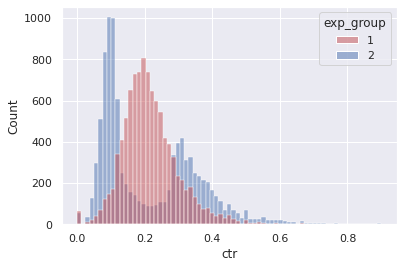

In [5]:
sns.set(rc={'figure.figsize':(11.7,8.27)})
groups = sns.histplot(data = df,
          x='ctr',
          hue='exp_group',
          palette = ['r', 'b'],
          alpha=0.5,
          kde=False)

In [6]:
# Записываю данные двух групп в более удобные переменные 

gr_1 = df[df.exp_group == 1].copy()
gr_2 = df[df.exp_group == 2].copy()

In [7]:
# Проведение t-теста на ctr. p-value заметно выше 0,05, тест не выявил различий между группами.
# Думаю, результат может быть обусловлен ненормальностью распределения в группе 2 

print(stats.ttest_ind(gr_1.ctr, gr_2.ctr, equal_var=False))

Ttest_indResult(statistic=0.4051491913112757, pvalue=0.685373331140751)


In [8]:
# Тест Манна-Уитни. p-value очень маленький, тест "прокрасился", различия статистически значимы 

print(stats.mannwhitneyu(gr_1.ctr, gr_2.ctr, alternative = 'two-sided'))

MannwhitneyuResult(statistic=55189913.0, pvalue=4.632205841806026e-45)


In [9]:
# Функция подсчета сглаженного CTR

def get_smoothed_ctr(user_likes, user_views, global_ctr, alpha):
        smoothed_ctr = (user_likes + alpha * global_ctr) / (user_views + alpha)
        return smoothed_ctr

In [10]:
# Расчет глобальных CTR по группам 1 и 2 

global_ctr_1 = gr_1.likes.sum()/gr_1.views.sum()
global_ctr_2 = gr_1.likes.sum()/gr_2.views.sum()

In [11]:
# Расчет сглаженного CTR 

gr_1['smoothed_ctr'] = gr_1.apply(lambda x: get_smoothed_ctr(x['likes'], x['views'], global_ctr_1, 5), axis=1)
gr_2['smoothed_ctr'] = gr_2.apply(lambda x: get_smoothed_ctr(x['likes'], x['views'], global_ctr_2, 5), axis=1)

In [12]:
# t-тест на сглаженном CTR 
# Снова p-value выше значения в 0,05, тест различий не нашел

print(stats.ttest_ind(gr_1.smoothed_ctr, gr_2.smoothed_ctr, equal_var=False))

Ttest_indResult(statistic=1.004474009919184, pvalue=0.3151658032194578)


In [13]:
# Функция бутстрепа 

def bootstrap(likes1, views1, likes2, views2, n_bootstrap=2000):
        poisson_bootstraps1 = stats.poisson(1).rvs((n_bootstrap, len(likes1))).astype(np.int64)
        poisson_bootstraps2 = stats.poisson(1).rvs((n_bootstrap, len(likes2))).astype(np.int64)
        
        globalCTR1 = (poisson_bootstraps1*likes1).sum(axis=1)/(poisson_bootstraps1*views1).sum(axis=1)  
        globalCTR2 = (poisson_bootstraps2*likes2).sum(axis=1)/(poisson_bootstraps2*views2).sum(axis=1)
        return globalCTR1, globalCTR2

In [14]:
likes1 = gr_1.likes.to_numpy()
views1 = gr_1.views.to_numpy()
likes2 = gr_2.likes.to_numpy()
views2 = gr_2.views.to_numpy()
bootstrap_ctr1, bootstrap_ctr2 = bootstrap(likes1, views1, likes2, views2)

<Axes: ylabel='Count'>

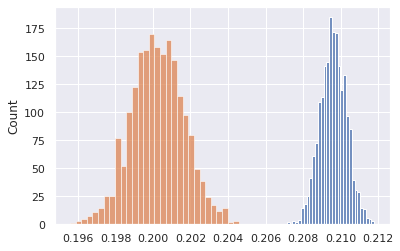

In [15]:
sns.histplot(bootstrap_ctr1)
sns.histplot(bootstrap_ctr2)

In [16]:
# На графике видно, что распределения групповых CTR даже не пересекаются, одно заметно больше другого.
# Это говорит о значимом различии между группами 

<Axes: ylabel='Count'>

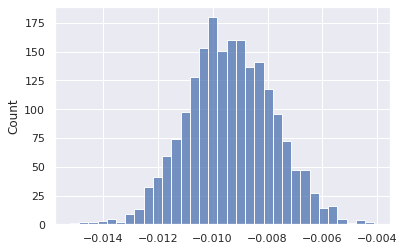

In [17]:
#Разница между глобальными CTR
sns.histplot(bootstrap_ctr2 - bootstrap_ctr1)

In [18]:
# Разница отрицательная и ненулевая, что говорит о том, что группы отличаются. 
# Группа 1 (контрольная) показала лучший результат по CTR, чем группа 2 (таргет).
# Бутстреп очень чувствительный и не зависящий от форм распределения тест

In [19]:
q_bucket = """
 SELECT exp_group, bucket,
   sum(likes)/sum(views) as bucket_ctr,
   quantileExact(0.9)(ctr) as ctr9
 FROM (SELECT exp_group,
       xxHash64(user_id)%50 as bucket,
       user_id,
       sum(action = 'like') as likes,
       sum(action = 'view') as views,
       likes/views as ctr
   FROM {db}.feed_actions
   WHERE toDate(time) between '2026-01-02' and '2026-01-08'
       and exp_group in (1,2)
   GROUP BY exp_group, bucket, user_id)
 GROUP BY exp_group, bucket
 """
 
df_bucket = pandahouse.read_clickhouse(q_bucket, connection=connection)

In [20]:
gr_1_bucket = df_bucket[df_bucket.exp_group == 1]
gr_2_bucket = df_bucket[df_bucket.exp_group == 2]

In [21]:
# Тест Манна-Уитни на данных, разбитых на 50 бакетов. 
# Различия статистически значимы исходя из результатов теста 

print(stats.mannwhitneyu(gr_1_bucket.bucket_ctr, gr_2_bucket.bucket_ctr, alternative = 'two-sided'))

MannwhitneyuResult(statistic=1997.0, pvalue=2.6576427804010095e-07)


<Axes: xlabel='bucket_ctr', ylabel='Count'>

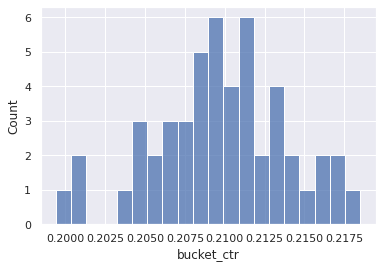

In [22]:
sns.histplot(gr_1_bucket.bucket_ctr, bins=20)

In [23]:
# Распределение группы 1 немного похоже на нормальное (унимодально, почти симметрично от-но максимума)

<Axes: xlabel='bucket_ctr', ylabel='Count'>

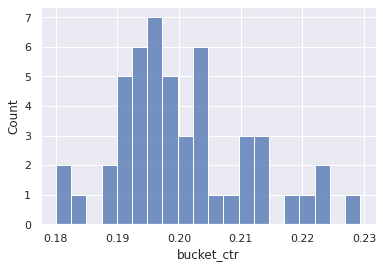

In [24]:
sns.histplot(gr_2_bucket.bucket_ctr, bins=20)

In [25]:
# Распределение группы 2 не так похоже на нормальное, однако тоже унимодально и почти симметрично, даже более колокообразное 

In [26]:
# t-тест также показывает значимые различия на данных, разбитых на бакеты 

print(stats.ttest_ind(gr_1_bucket.bucket_ctr, gr_2_bucket.bucket_ctr, equal_var=False))

Ttest_indResult(statistic=5.614819358149381, pvalue=4.592644937473873e-07)


In [27]:
print(stats.mannwhitneyu(gr_1_bucket.ctr9, gr_2_bucket.ctr9, alternative = 'two-sided'))

MannwhitneyuResult(statistic=0.0, pvalue=6.7601631082665925e-18)


In [28]:
# Исходя из всех тестов я делаю вывод о том, что группы различаются статистически значимо.
# Различий не увидели только t-тест на обычном ctr каждого пользователя и t-тест на сглаженном ctr. 
# В первом случае я думаю виновата форма распределения группы 2, а во втором сомнительность сглаженного ctr в целом, 
# его исследование не дает гарантий.
# Остальные тесты показали различия, причем благодаря бутстрепу можно сказать, что показатели ctr в 
# экспериментальной группе даже хуже, чем в контрольной. Т.е. новые алгоритмы рекомендации постов не показали 
# себя, как более выигрышные, раскатывать их на всех пользователей будет ошибкой. Однако на графике видны два пика,
# один из которых правее пика у контрольной группы. Так что для части пользователей новый альгоритм даже лучше

# Возможные причины такого результата: 
# 1. Новый алгоритм хорошо работает только на старых пользователях (больше данных), они стали лайкать больше (второй пик)
# 2. Новый алгоритм по-разному влияет на разные типы пользователей, а старый "сглаживал" ситуацию